In [29]:
import torch
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim


In [30]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [31]:
torch.manual_seed(42)
df=pd.read_csv("fmnist_small.csv")
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,1,0,0,0,0,0,0,0,0,0,...,69,12,0,0,0,0,0,0,0,0
5996,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5997,8,0,0,0,0,0,0,0,0,0,...,39,47,2,0,0,29,0,0,0,0
5998,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
df.shape

(6000, 785)

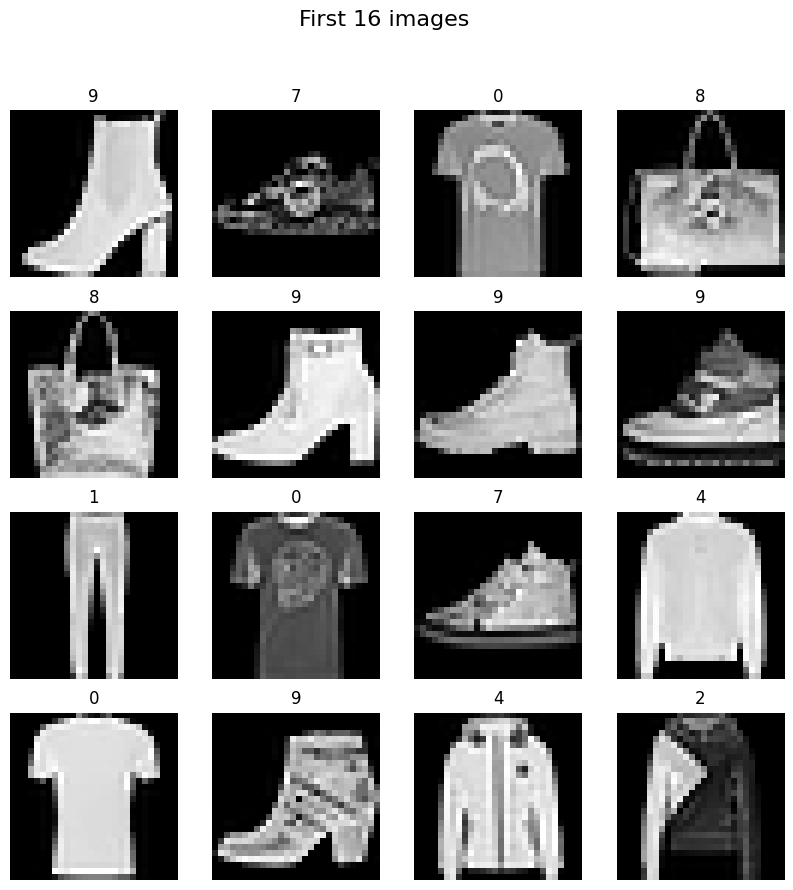

In [33]:
fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("First 16 images",fontsize=16)

for i,ax in enumerate(axes.flat):
    img=df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img,cmap="gray")
    ax.axis("off")
    ax.set_title(df.iloc[i,0])
plt.show()

In [34]:
len(df['label'].unique())

10

In [35]:
X=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
# scaling the feautures

X_train = X_train/255.0
X_test = X_test/255.0

In [38]:
class custom_dataset(Dataset):
    def __init__(self,features,labels):
        self.features=torch.tensor(features,dtype=torch.float32)
        self.labels=torch.tensor(labels)
        self.len=self.labels.shape[0]

    def __len__(self):
        return len(self.features)

    def __getitem__(self,index):
        return self.features[index],self.labels[index]


In [39]:
train_dataset = custom_dataset(X_train,y_train)
test_dataset = custom_dataset(X_test,y_test)
len(train_dataset)

4800

In [49]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

#Pin_memory speeds up data transfer from cpu to gpu

In [50]:
class MyNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()

    self.model = nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10),

    )

  def forward(self,X):
    return self.model(X)

In [42]:
epochs = 100
learning_rate = 0.1

In [43]:
model = MyNN(X_train.shape[1])

model = model.to(device)

# loss function
criterion = nn.CrossEntropyLoss()
# optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [44]:
# training loop

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = model(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


Epoch: 1 , Loss: 1.3216368587811789
Epoch: 2 , Loss: 0.779336541891098
Epoch: 3 , Loss: 0.6427524608373641
Epoch: 4 , Loss: 0.5751657414436341
Epoch: 5 , Loss: 0.5278772541880608
Epoch: 6 , Loss: 0.49531100074450174
Epoch: 7 , Loss: 0.46192684868971506
Epoch: 8 , Loss: 0.4355265040695667
Epoch: 9 , Loss: 0.41890643616517387
Epoch: 10 , Loss: 0.39741520086924237
Epoch: 11 , Loss: 0.38665723502635957
Epoch: 12 , Loss: 0.37127780785163245
Epoch: 13 , Loss: 0.34902072985967
Epoch: 14 , Loss: 0.3476298343638579
Epoch: 15 , Loss: 0.315855147143205
Epoch: 16 , Loss: 0.31195787360270816
Epoch: 17 , Loss: 0.2958236853778362
Epoch: 18 , Loss: 0.2882651568452517
Epoch: 19 , Loss: 0.2712535865108172
Epoch: 20 , Loss: 0.2599384474754334
Epoch: 21 , Loss: 0.2577110414206982
Epoch: 22 , Loss: 0.24670669116079808
Epoch: 23 , Loss: 0.23920624203979968
Epoch: 24 , Loss: 0.22601549635330836
Epoch: 25 , Loss: 0.2235869560142358
Epoch: 26 , Loss: 0.21268803268671035
Epoch: 27 , Loss: 0.21945507449408372
Ep

In [45]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [46]:
# evaluation code testing
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()


In [47]:
print(correct/total)

0.8241666666666667


In [48]:
# evaluation code training
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.99875
